<a href="https://colab.research.google.com/github/va4756/bigdata_raejung/blob/main/quebin_data_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01.DCGAN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys

# 코랩의 경우 깃허브 저장소로부터 utils.py를 다운로드 합니다.
if 'google.colab' in sys.modules:
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
    !mkdir -p notebooks
    !mv utils.py notebooks

--2026-05-08 08:21:22--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 771 [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]     771  --.-KB/s    in 0s      

2026-05-08 08:21:22 (61.7 MB/s) - ‘utils.py’ saved [771/771]



In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    losses,
    utils,
    metrics,
    optimizers,
)

from notebooks.utils import display, sample_batch

In [24]:
IMAGE_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 128
Z_DIM = 100
# EPOCHS = 100 # 훈련이 오래 걸려 에포크 횟수를 300에서 100으로 줄입니다.
EPOCHS = 2
LOAD_MODEL = False
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999
LEARNING_RATE = 0.002
NOISE_PARAM = 0.1

In [5]:
# 코랩일 경우 노트북에서 celeba 데이터셋을 받습니다.
if 'google.colab' in sys.modules:
    # # 캐글-->Setttings-->API-->Create New Token에서
    # # kaggle.json 파일을 만들어 코랩에 업로드하세요.
    # from google.colab import files
    # files.upload()
    # !mkdir ~/.kaggle
    # !cp kaggle.json ~/.kaggle/
    # !chmod 600 ~/.kaggle/kaggle.json
    # 데이터셋을 다운로드하고 압축을 해제합니다.
    !kaggle datasets download -d joosthazelzet/lego-brick-images
    #
    # 캐글에서 다운로드가 안 될 경우 역자의 드라이브에서 다운로드할 수 있습니다.
    # import gdown
    # gdown.download(id='1qd50QDZtr_NYFiFVdp0sIvGDwTT3mMEQ')
    !unzip -q lego-brick-images.zip
    # output 디렉토리를 만듭니다.
    !mkdir output

Dataset URL: https://www.kaggle.com/datasets/joosthazelzet/lego-brick-images
License(s): GPL-2.0
100% 1.00G/1.00G [00:57<00:00, 18.5MB/s]



In [6]:
train_data = utils.image_dataset_from_directory(
    "./dataset/",
    labels=None,
    color_mode="grayscale",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    interpolation="bilinear",
)

Found 40000 files.


In [7]:
def preprocess(img):
    """
    이미지 정규화 및 크기 변경
    """
    img = (tf.cast(img, "float32") - 127.5) / 127.5
    return img


train = train_data.map(lambda x: preprocess(x))

사용 장치: cuda
GPU 이름: Tesla T4
--------------------
Tensor Shape: torch.Size([32, 1, 64, 64])
Device: cuda:0
--------------------
Min: -1.0
Max: 0.2627451419830322


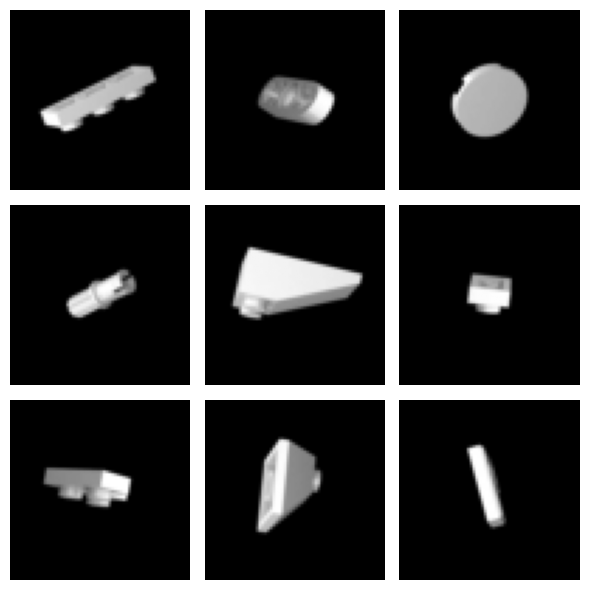

In [8]:
# PyTorch에서는 사용자 정의 Dataset 을 만들어야 합니다.
# 아래 코드는 TensorFlow 코드와 거의 동일하게 동작합니다.

import os
import shutil
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets

import matplotlib.pyplot as plt

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용 장치:", device)

# GPU 이름 출력
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

# 설정값
IMAGE_SIZE = 64
BATCH_SIZE = 32

# Transform
# [0,255] -> [-1,1]
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),                # [0,255] -> [0,1]
    transforms.Normalize((0.5,), (0.5,))  # [0,1] -> [-1,1]
])

# Custom Dataset
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.image_paths = [
            os.path.join(root_dir, fname)
            for fname in os.listdir(root_dir)
            if fname.lower().endswith(
                (".png", ".jpg", ".jpeg", ".bmp")
            )
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)

        return image

# Dataset 생성
train_dataset = CustomImageDataset(
    root_dir='./dataset/',
    transform=transform
)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# sample_batch
def sample_batch(dataloader):
    images = next(iter(dataloader))

    # GPU 이동
    images = images.to(device)

    return images

# 샘플 추출
train_sample = sample_batch(train_loader)

print('-'*20)
print("Tensor Shape:", train_sample.shape)
print("Device:", train_sample.device)
print('-'*20)
print("Min:", train_sample.min().item())
print("Max:", train_sample.max().item())

# GPU -> CPU 변환 후 시각화
images_cpu = train_sample.cpu()
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    img = images_cpu[i].squeeze().numpy()

    # [-1,1] -> [0,1]
    img = (img + 1) / 2

    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
# DCGAN (PyTorch GPU Version for Google Colab)
# TensorFlow → PyTorch 완전 변환 버전
# 1. Discriminator(식별자)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128, momentum=0.9),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256, momentum=0.9),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512, momentum=0.9),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

In [10]:
# 2. Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(Z_DIM, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512, momentum=0.9),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256, momentum=0.9),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128, momentum=0.9),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64, momentum=0.9),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [11]:
# 3. 모델 생성
generator = Generator().to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), paddin

In [12]:
# 4. Loss & Optimizer
criterion = nn.BCELoss()

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(ADAM_BETA_1, ADAM_BETA_2)
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(ADAM_BETA_1, ADAM_BETA_2)
)

In [22]:
# 5. 생성 이미지 저장
os.makedirs("./output", exist_ok=True)

def save_generated_images(epoch):
    z = torch.randn(16, Z_DIM, 1, 1).to(device)

    with torch.no_grad():
        fake_images = generator(z)

    fake_images = (fake_images + 1) / 2
    fig = plt.figure(figsize=(6, 6))

    for i in range(16):
        plt.subplot(4, 4, i+1)
        img = fake_images[i].detach().cpu().squeeze()

        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(f"./output/generated_epoch_{epoch:03d}.png")
    plt.close()

In [27]:
# 6. Training Loop
for epoch in range(EPOCHS):

    generator.train()
    discriminator.train()

    g_losses = []
    d_losses = []

    for real_images in train_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Discriminator Training
        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # noisy labels
        real_labels = real_labels - NOISE_PARAM * torch.rand_like(real_labels)
        fake_labels = fake_labels + NOISE_PARAM * torch.rand_like(fake_labels)

        z = torch.randn(batch_size, Z_DIM, 1, 1).to(device)

        fake_images = generator(z)

        real_preds = discriminator(real_images)
        fake_preds = discriminator(fake_images.detach())

        d_real_loss = criterion(real_preds, real_labels)
        d_fake_loss = criterion(fake_preds, fake_labels)

        d_loss = (d_real_loss + d_fake_loss) / 2

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Generator Training
        z = torch.randn(batch_size, Z_DIM, 1, 1).to(device)

        fake_images = generator(z)
        fake_preds = discriminator(fake_images)

        g_loss = criterion(
            fake_preds,
            torch.ones_like(fake_preds)
        )
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    # Epoch 결과 출력
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"D Loss: {np.mean(d_losses):.4f} "
        f"G Loss: {np.mean(g_losses):.4f}"
    )

    # 이미지 저장
    if epoch % 10 == 0:
        save_generated_images(epoch)

Epoch [1/10] D Loss: 0.3476 G Loss: 2.4816
Epoch [2/10] D Loss: 0.3637 G Loss: 2.4135
Epoch [3/10] D Loss: 0.3459 G Loss: 2.5178
Epoch [4/10] D Loss: 0.3450 G Loss: 2.4920
Epoch [5/10] D Loss: 0.3402 G Loss: 2.5930
Epoch [6/10] D Loss: 0.3399 G Loss: 2.5774


KeyboardInterrupt: 

In [28]:
# 7. 모델 저장
torch.save(generator.state_dict(), "generator.pth")
torch.save(discriminator.state_dict(), "discriminator.pth")
print("모델 저장 완료")

모델 저장 완료


In [29]:
# 8. 이미지 생성
generator.eval()
z = torch.randn(30, Z_DIM, 1, 1).to(device)

with torch.no_grad():
    generated_images = generator(z)

generated_images = (generated_images + 1) / 2

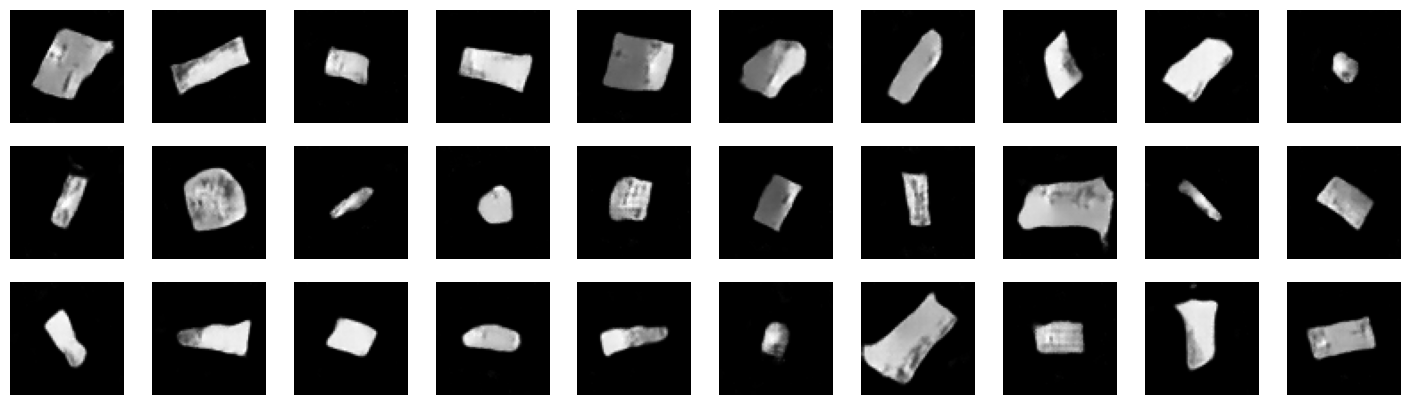

In [30]:
# 9. 생성 결과 출력
fig = plt.figure(figsize=(18, 5))

for i in range(30):
    ax = fig.add_subplot(3, 10, i+1)
    img = generated_images[i].detach().cpu().squeeze()
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.show()

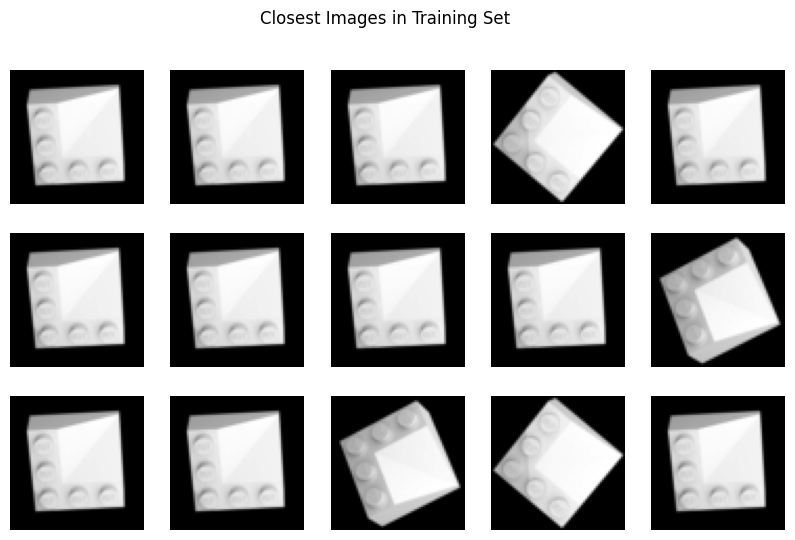

In [32]:
# 10. 가장 유사한 훈련 이미지 찾기
all_data = []

for imgs in train_loader:
    all_data.append(imgs)

all_data = torch.cat(all_data, dim=0)

def compare_images(img1, img2):
    return torch.mean(torch.abs(img1 - img2)).item()

r, c= 3, 5

fig, axs = plt.subplots(r, c, figsize=(10, 6))

cnt = 0
for i in range(r):
    for j in range(c):
        gen_img = generated_images[cnt].cpu()

        best_diff = 999999
        best_img = None

        for k in range(len(all_data)):
            diff = compare_images(gen_img, all_data[k])

            if diff < best_diff:
                best_diff = diff
                best_img = all_data[k]

        best_img = (best_img + 1) / 2

        axs[i, j].imshow(best_img.squeeze(), cmap='gray')
        axs[i, j].axis("off")

        cnt += 1

plt.suptitle("Closest Images in Training Set")
plt.show()

# 02.WGAN - CelebA 얼굴 데이터셋

### 구글 드라이브 시작

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import sys

# 코랩의 경우 깃허브 저장소로부터 utils.py를 다운로드 합니다.
if 'google.colab' in sys.modules:
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
    !mkdir -p notebooks
    !mv utils.py notebooks

--2026-05-08 09:43:46--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 771 [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]     771  --.-KB/s    in 0s      

2026-05-08 09:43:46 (40.1 MB/s) - ‘utils.py’ saved [771/771]



In [35]:
import numpy as np

import tensorflow as tf
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    optimizers,
)

from notebooks.utils import display, sample_batch

In [37]:
# 코랩일 경우 노트북에서 celeba 데이터셋을 받습니다.
if 'google.colab' in sys.modules:
    # # 캐글-->Setttings-->API-->Create New Token에서
    # # kaggle.json 파일을 만들어 코랩에 업로드하세요.
    # from google.colab import files
    # files.upload()
    # !mkdir ~/.kaggle
    # !cp kaggle.json ~/.kaggle/
    # !chmod 600 ~/.kaggle/kaggle.json
    # # celeba 데이터셋을 다운로드하고 압축을 해제합니다.
    # !kaggle datasets download -d jessicali9530/celeba-dataset
    # 캐글에서 다운로드가 안 될 경우 역자의 드라이브에서 다운로드할 수 있습니다.
    import gdown
    gdown.download(id='15gJhiDBkltMQz3T97xG-fO4gXTKAWkSB')
    !unzip -q celeba-dataset.zip
    # output 디렉토리를 만듭니다.
    !mkdir output

Downloading...
From (original): https://drive.google.com/uc?id=15gJhiDBkltMQz3T97xG-fO4gXTKAWkSB
From (redirected): https://drive.google.com/uc?id=15gJhiDBkltMQz3T97xG-fO4gXTKAWkSB&confirm=t&uuid=041dcedc-23cf-463c-af32-c5b295251931
To: /content/celeba-dataset.zip
100%|██████████| 1.43G/1.43G [00:31<00:00, 44.7MB/s]


mkdir: cannot create directory ‘output’: File exists


In [38]:
# 데이터 로드
train_data = utils.image_dataset_from_directory(
    "./img_align_celeba/img_align_celeba",
    labels=None,
    color_mode="rgb",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    interpolation="bilinear",
)

Found 202599 files.


In [39]:
# 데이터 전처리
def preprocess(img):
    """
    이미지 정규화 및 크기 변경
    """
    img = (tf.cast(img, "float32") - 127.5) / 127.5
    return img


train = train_data.map(lambda x: preprocess(x))

In [40]:
# 훈련 세트에 있는 몇 개의 샘플 출력
train_sample = sample_batch(train)

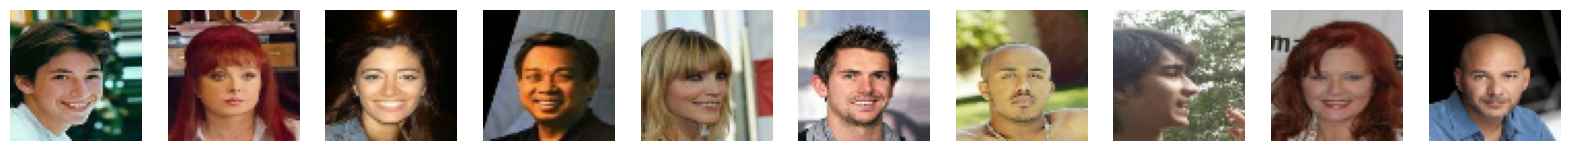

In [41]:
display(train_sample, cmap=None)

In [36]:
IMAGE_SIZE = 64
CHANNELS = 3
BATCH_SIZE = 512
NUM_FEATURES = 64
Z_DIM = 128
LEARNING_RATE = 0.0002
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999
EPOCHS = 200
CRITIC_STEPS = 3
GP_WEIGHT = 10.0
LOAD_MODEL = False
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.9

In [ ]:
# PyTorch에서는 사용자 정의 Dataset 을 만들어야 합니다.
# 아래 코드는 TensorFlow 코드와 거의 동일하게 동작합니다.

import os
import shutil
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets

import matplotlib.pyplot as plt